In [280]:
# import core packages
import pandas as pd
import numpy as np
import os
import snowflake.connector as snow
import pyreadstat
import xlsxwriter
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import NamedStyle

# see all columns
pd.set_option('display.max_columns', None)

# define enviro variables
user = os.environ['USER']
username = os.environ["SNOWFLAKE_USER"]
sf_pass = os.environ["SNOWFLAKE_PASSWORD"]

# set working directory
os.chdir(f"/Users/{user}/Library/CloudStorage/GoogleDrive-{user}@opportunityatwork.org/Shared drives/Insights")
# see all columns
pd.set_option('display.max_columns', None)

# establish snowflake connection
conn = snow.connect(
    user=username,
    password=sf_pass,
    account='avb99459.us-east-1',
    warehouse='OPPORTUNITYATWORK_WH',
    role='PUBLIC'
)

cur = conn.cursor()

In [281]:
import pandas as pd

# Correct function for reading CSV files
ai_exposure = pd.read_csv("Projects/Ongoing/Tulsa STAR Workforce/Input/ai_exposure.csv")

# Show the dataframe
ai_exposure.head()

,O*NET-SOC Code,Title,gpt4_alpha,gpt4_beta,gpt4_gamma,human_alpha,human_beta,human_gamma,automation,automation_acemoglu,gpt4_alt_beta,OCC_CODE
0,11-1011.00,Chief Executives,0.096774,0.451613,0.806452,0.161290,0.338710,0.516129,0.362903,0.362903,0.306452,11-1011
1,11-1011.03,Chief Sustainability Officers,0.166667,0.555556,0.944444,0.055556,0.388889,0.722222,0.513889,0.513889,0.527778,11-1011
2,11-1021.00,General and Operations Managers,0.000000,0.470588,0.941176,0.117647,0.382353,0.647059,0.470588,0.470588,0.352941,11-1021
3,11-1031.00,Legislators,0.033333,0.400000,0.766667,0.266667,0.516667,0.766667,0.308333,0.308333,0.300000,11-1031
4,11-2011.00,Advertising and Promotions Managers,0.000000,0.466667,0.933333,0.200000,0.516667,0.833333,0.508333,0.508333,0.333333,11-2011


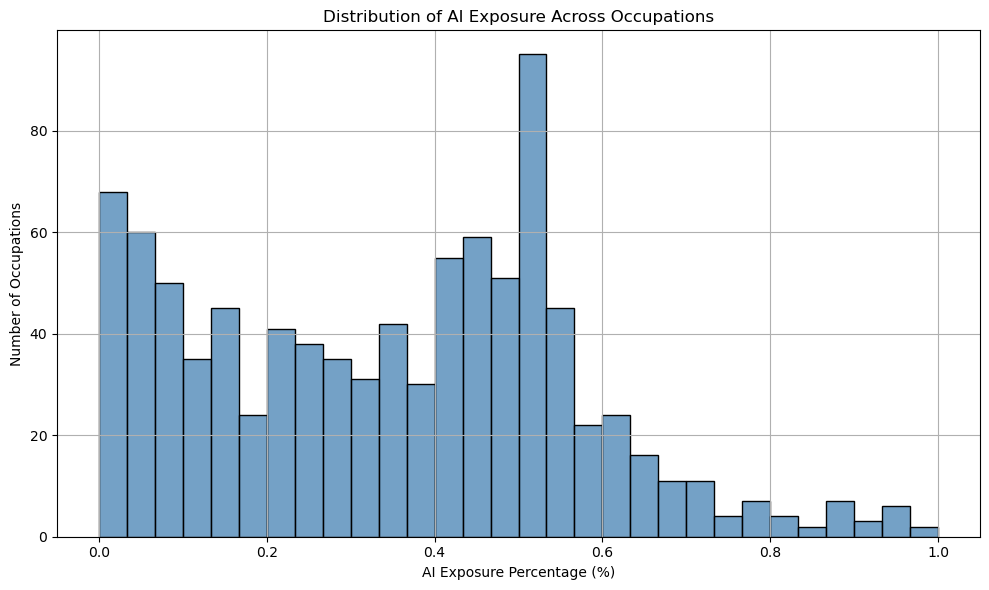

In [282]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make sure it's a numeric column
ai_exposure['gpt4_beta'] = pd.to_numeric(ai_exposure['gpt4_beta'], errors='coerce')

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(data=ai_exposure, x='gpt4_beta', bins=30, kde=False, color='steelblue')

# Formatting
plt.title('Distribution of AI Exposure Across Occupations')
plt.xlabel('AI Exposure Percentage (%)')
plt.ylabel('Number of Occupations')
plt.grid(True)
plt.tight_layout()
plt.show()

## Entry level jobs

In [ ]:
query = f'''
WITH total_postings AS (
    SELECT
        EXTRACT(YEAR FROM posted)::int AS year,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE year(posted) BETWEEN 2014 AND 2024
    GROUP BY year, soc_2021_5_name, soc_2021_5
),

entry_level_postings AS (
    SELECT
        EXTRACT(YEAR FROM posted)::int AS year,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE year(posted) BETWEEN 2014 AND 2024
      --AND (min_years_experience <= 1)
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed',
          'High school or GED',
          'Associate degree',
          'Bachelor''s Degree'
      )
    GROUP BY year, soc_2021_5_name, soc_2021_5
),

entry_level_share AS (
    SELECT
        tp.year,
        tp.soc_2021_5_name,
        tp.soc_2021_5,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(100.0 * COALESCE(elp.entry_level_postings, 0)::numeric / NULLIF(tp.total_postings, 0), 2) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp
        ON tp.year = elp.year AND tp.soc_2021_5_name = elp.soc_2021_5_name AND tp.soc_2021_5 = elp.soc_2021_5
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, soc_2021_5_name, entry_level_pct
'''

cur = conn.cursor().execute(query)
yoe_time_series = pd.DataFrame.from_records(iter(cur),
                               columns=[x[0] for x in cur.description])

yoe_time_series.columns = yoe_time_series.columns.str.lower()

In [283]:
query = f'''
WITH total_postings AS (
    SELECT
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2020 AND 2024
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_postings AS (
    SELECT
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2020 AND 2024
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed',
          'High school or GED',
          'Associate degree',
          'Bachelor''s Degree'
      )
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_share AS (
    SELECT
        tp.year_month,
        tp.year,
        tp.month,
        tp.soc_2021_5_name,
        tp.soc_2021_5,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(
            100.0 * COALESCE(elp.entry_level_postings, 0)::numeric
            / NULLIF(tp.total_postings, 0),
            2
        ) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp
        ON tp.year_month = elp.year_month
       AND tp.soc_2021_5_name = elp.soc_2021_5_name
       AND tp.soc_2021_5 = elp.soc_2021_5
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, month, soc_2021_5_name, entry_level_pct
'''

cur = conn.cursor().execute(query)
yoe_time_series = pd.DataFrame.from_records(
    iter(cur),
    columns=[x[0] for x in cur.description]
)

yoe_time_series.columns = yoe_time_series.columns.str.lower()

In [284]:
yoe_time_series.head(20)

,year_month,year,month,soc_2021_5_name,soc_2021_5,total_postings,entry_level_postings,entry_level_pct
0,2020-01-01,2020,1,Accountants and Auditors,13-2011,37873,1837.0,4.85
1,2020-01-01,2020,1,Actors,27-2011,614,41.0,6.68
2,2020-01-01,2020,1,Actuaries,15-2011,1272,54.0,4.25
3,2020-01-01,2020,1,Acupuncturists,29-1291,169,8.0,4.73
4,2020-01-01,2020,1,Adhesive Bonding Machine Operators and Tenders,51-9191,898,129.0,14.37
5,2020-01-01,2020,1,Administrative Services Managers,11-3012,2451,217.0,8.85
6,2020-01-01,2020,1,"Adult Basic Education, Adult Secondary Educati...",25-3011,784,62.0,7.91
7,2020-01-01,2020,1,Advertising Sales Agents,41-3011,8113,1331.0,16.41
8,2020-01-01,2020,1,Advertising and Promotions Managers,11-2011,541,49.0,9.06
9,2020-01-01,2020,1,Aerospace Engineers,17-2011,834,17.0,2.04


In [ ]:
yoe_time_series.to_csv('/Users/khaliun/Downloads/yoe_time_series.csv', index=False)

In [285]:
# 1. Rename the occupation code column to match ai_exposure
yoe_time_series = yoe_time_series.rename(columns={'soc_2021_5': 'OCC_CODE'})

# 2. Ensure both columns are the same dtype (int or str, depending on how codes are formatted)
yoe_time_series['OCC_CODE'] = yoe_time_series['OCC_CODE'].astype(str)
ai_exposure['OCC_CODE'] = ai_exposure['OCC_CODE'].astype(str)

# 3. Merge GPT-4 exposure scores into the time series dataset
yoe_full = yoe_time_series.merge(
    ai_exposure[['OCC_CODE', 'gpt4_beta']],
    on='OCC_CODE',
    how='left'
)

# 4. View result
print(yoe_full[['OCC_CODE', 'year','month', 'entry_level_pct', 'gpt4_beta']].head())

  OCC_CODE  year  month entry_level_pct  gpt4_beta
0  13-2011  2020      1            4.85   0.550000
1  27-2011  2020      1            6.68   0.184211
2  15-2011  2020      1            4.25   0.500000
3  29-1291  2020      1            4.73   0.166667
4  51-9191  2020      1           14.37   0.058824


In [286]:
import numpy as np
import pandas as pd

# Make sure the numeric columns are floats (not Decimal, not strings)
for col in ['entry_level_pct', 'gpt4_beta']:
    if col in yoe_full.columns:
        yoe_full[col] = pd.to_numeric(yoe_full[col], errors='coerce')

In [287]:
print(yoe_full[['OCC_CODE','year','entry_level_pct','gpt4_beta']].dtypes)

OCC_CODE            object
year                 int64
entry_level_pct    float64
gpt4_beta          float64
dtype: object


In [288]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta
0,2020-01-01,2020,1,Accountants and Auditors,13-2011,37873,1837.0,4.85,0.550000
1,2020-01-01,2020,1,Actors,27-2011,614,41.0,6.68,0.184211
2,2020-01-01,2020,1,Actuaries,15-2011,1272,54.0,4.25,0.500000
3,2020-01-01,2020,1,Acupuncturists,29-1291,169,8.0,4.73,0.166667
4,2020-01-01,2020,1,Adhesive Bonding Machine Operators and Tenders,51-9191,898,129.0,14.37,0.058824
...,...,...,...,...,...,...,...,...,...
45226,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,293,74.0,25.26,0.038462
45227,2024-12-01,2024,12,Word Processors and Typists,43-9022,513,74.0,14.42,0.750000
45228,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000
45229,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000


In [289]:
import statsmodels.formula.api as smf
import numpy as np

df = yoe_full.copy()
df["month"] = df["month"].astype(int)

# month-only seasonality (11 dummies implicitly via C(month))
m = smf.ols("entry_level_pct ~ C(month)", data=df.dropna(subset=["entry_level_pct","month"])).fit()

df["entry_resid"] = m.resid

# optional: put residuals back onto a percent-like level (centered at overall mean)
df["entry_sa"] = df["entry_resid"] + df["entry_level_pct"].mean()

yoe_full = df

In [290]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa
0,2020-01-01,2020,1,Accountants and Auditors,13-2011,37873,1837.0,4.85,0.550000,-7.843064,4.681375
1,2020-01-01,2020,1,Actors,27-2011,614,41.0,6.68,0.184211,-6.013064,6.511375
2,2020-01-01,2020,1,Actuaries,15-2011,1272,54.0,4.25,0.500000,-8.443064,4.081375
3,2020-01-01,2020,1,Acupuncturists,29-1291,169,8.0,4.73,0.166667,-7.963064,4.561375
4,2020-01-01,2020,1,Adhesive Bonding Machine Operators and Tenders,51-9191,898,129.0,14.37,0.058824,1.676936,14.201375
...,...,...,...,...,...,...,...,...,...,...,...
45226,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,293,74.0,25.26,0.038462,12.500242,25.024681
45227,2024-12-01,2024,12,Word Processors and Typists,43-9022,513,74.0,14.42,0.750000,1.660242,14.184681
45228,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000,-2.969758,9.554681
45229,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000,-2.969758,9.554681


## Occ weight share of overall in 2021

In [291]:
query = f'''
WITH occ_2021 AS (
    SELECT
        soc_2021_5,
        soc_2021_5_name,
        COUNT(DISTINCT id) AS total_postings_2021
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int = 2021
    GROUP BY soc_2021_5, soc_2021_5_name
),
total_2021 AS (
    SELECT
        SUM(total_postings_2021) AS total_postings_2021_all
    FROM occ_2021
)
SELECT
    o.soc_2021_5,
    o.soc_2021_5_name,
    o.total_postings_2021,
    (o.total_postings_2021::numeric / t.total_postings_2021_all) AS w_2021
FROM occ_2021 o
CROSS JOIN total_2021 t
ORDER BY w_2021 DESC;
'''

cur = conn.cursor().execute(query)
occ2021_weight = pd.DataFrame.from_records(iter(cur),
                               columns=[x[0] for x in cur.description])

occ2021_weight.columns = occ2021_weight.columns.str.lower()

In [292]:
occ2021_weight

,soc_2021_5,soc_2021_5_name,total_postings_2021,w_2021
0,29-1141,Registered Nurses,2037404,0.046651
1,41-2031,Retail Salespersons,1187603,0.027193
2,53-3032,Heavy and Tractor-Trailer Truck Drivers,1169755,0.026784
3,15-1252,Software Developers,1072454,0.024556
4,43-4051,Customer Service Representatives,969400,0.022197
...,...,...,...,...
762,49-2092,"Electric Motor, Power Tool, and Related Repairers",16,0.000000
763,51-6042,Shoe Machine Operators and Tenders,16,0.000000
764,51-7032,"Patternmakers, Wood",8,0.000000
765,53-7031,Dredge Operators,17,0.000000


In [293]:
# assume occ2021_weight already has a 'w_2021' column that sums to 1
occ2021_weight['w_2021_pct'] = (occ2021_weight['w_2021'] * 100).round(4)

print(occ2021_weight.head())

  soc_2021_5                          soc_2021_5_name  total_postings_2021  \
0    29-1141                        Registered Nurses              2037404   
1    41-2031                      Retail Salespersons              1187603   
2    53-3032  Heavy and Tractor-Trailer Truck Drivers              1169755   
3    15-1252                      Software Developers              1072454   
4    43-4051         Customer Service Representatives               969400   

     w_2021 w_2021_pct  
0  0.046651   4.665100  
1  0.027193   2.719300  
2  0.026784   2.678400  
3  0.024556   2.455600  
4  0.022197   2.219700  


In [294]:
# make sure codes match
yoe_full["OCC_CODE"] = yoe_full["OCC_CODE"].astype(str)
occ2021_weight["soc_2021_5"] = occ2021_weight["soc_2021_5"].astype(str)

yoe_full = yoe_full.merge(
    occ2021_weight[["soc_2021_5", "w_2021"]],
    left_on="OCC_CODE",
    right_on="soc_2021_5",
    how="left"
)
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa,soc_2021_5,w_2021
0,2020-01-01,2020,1,Accountants and Auditors,13-2011,37873,1837.0,4.85,0.550000,-7.843064,4.681375,13-2011,0.007812
1,2020-01-01,2020,1,Actors,27-2011,614,41.0,6.68,0.184211,-6.013064,6.511375,27-2011,0.000265
2,2020-01-01,2020,1,Actuaries,15-2011,1272,54.0,4.25,0.500000,-8.443064,4.081375,15-2011,0.000258
3,2020-01-01,2020,1,Acupuncturists,29-1291,169,8.0,4.73,0.166667,-7.963064,4.561375,29-1291,0.000047
4,2020-01-01,2020,1,Adhesive Bonding Machine Operators and Tenders,51-9191,898,129.0,14.37,0.058824,1.676936,14.201375,51-9191,0.000280
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45226,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,293,74.0,25.26,0.038462,12.500242,25.024681,49-9081,0.000087
45227,2024-12-01,2024,12,Word Processors and Typists,43-9022,513,74.0,14.42,0.750000,1.660242,14.184681,43-9022,0.000274
45228,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000,-2.969758,9.554681,27-3043,0.001103
45229,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000,-2.969758,9.554681,27-3043,0.001103


In [295]:
# pick one occupation and show all its rows (sorted by time)

occ = "13-2011"  # <-- replace with the OCC_CODE you want

one_occ = (
    yoe_full[yoe_full["OCC_CODE"].astype(str) == str(occ)]
    .sort_values(["year", "month"])
)

one_occ

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa,soc_2021_5,w_2021
0,2020-01-01,2020,1,Accountants and Auditors,13-2011,37873,1837.0,4.85,0.55,-7.843064,4.681375,13-2011,0.007812
749,2020-02-01,2020,2,Accountants and Auditors,13-2011,40609,1873.0,4.61,0.55,-8.141782,4.382657,13-2011,0.007812
1499,2020-03-01,2020,3,Accountants and Auditors,13-2011,34912,1712.0,4.90,0.55,-7.820621,4.703818,13-2011,0.007812
2246,2020-04-01,2020,4,Accountants and Auditors,13-2011,20196,846.0,4.19,0.55,-8.257454,4.266985,13-2011,0.007812
2966,2020-05-01,2020,5,Accountants and Auditors,13-2011,19151,872.0,4.55,0.55,-7.873551,4.650888,13-2011,0.007812
3697,2020-06-01,2020,6,Accountants and Auditors,13-2011,22699,925.0,4.08,0.55,-8.205977,4.318462,13-2011,0.007812
4441,2020-07-01,2020,7,Accountants and Auditors,13-2011,20664,797.0,3.86,0.55,-8.414430,4.110009,13-2011,0.007812
5183,2020-08-01,2020,8,Accountants and Auditors,13-2011,20974,1011.0,4.82,0.55,-7.524672,4.999767,13-2011,0.007812
5928,2020-09-01,2020,9,Accountants and Auditors,13-2011,21157,992.0,4.69,0.55,-7.826941,4.697498,13-2011,0.007812
6665,2020-10-01,2020,10,Accountants and Auditors,13-2011,23053,1338.0,5.80,0.55,-6.727619,5.796820,13-2011,0.007812


In [296]:
import statsmodels.formula.api as smf
import numpy as np

df = yoe_full.copy()
df["month"] = df["month"].astype(int)

# regress on month-of-year dummies (Jan omitted automatically)
m = smf.ols("entry_level_pct ~ C(month)", data=df.dropna(subset=["entry_level_pct"])).fit()

# residuals = entry-level share with seasonality removed
df["entry_resid"] = m.resid

# put residuals back on a percent-like scale (important for indexing)
df["entry_sa"] = df["entry_resid"] + df["entry_level_pct"].mean()

yoe_full = df

In [297]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa,soc_2021_5,w_2021
0,2020-01-01,2020,1,Accountants and Auditors,13-2011,37873,1837.0,4.85,0.550000,-7.843064,4.681375,13-2011,0.007812
1,2020-01-01,2020,1,Actors,27-2011,614,41.0,6.68,0.184211,-6.013064,6.511375,27-2011,0.000265
2,2020-01-01,2020,1,Actuaries,15-2011,1272,54.0,4.25,0.500000,-8.443064,4.081375,15-2011,0.000258
3,2020-01-01,2020,1,Acupuncturists,29-1291,169,8.0,4.73,0.166667,-7.963064,4.561375,29-1291,0.000047
4,2020-01-01,2020,1,Adhesive Bonding Machine Operators and Tenders,51-9191,898,129.0,14.37,0.058824,1.676936,14.201375,51-9191,0.000280
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45226,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,293,74.0,25.26,0.038462,12.500242,25.024681,49-9081,0.000087
45227,2024-12-01,2024,12,Word Processors and Typists,43-9022,513,74.0,14.42,0.750000,1.660242,14.184681,43-9022,0.000274
45228,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000,-2.969758,9.554681,27-3043,0.001103
45229,2024-12-01,2024,12,Writers and Authors,27-3043,2166,212.0,9.79,0.875000,-2.969758,9.554681,27-3043,0.001103


In [298]:
# make sure codes match
yoe_full["OCC_CODE"] = yoe_full["OCC_CODE"].astype(str)
occ2021_weight["soc_2021_5"] = occ2021_weight["soc_2021_5"].astype(str)

# Drop existing w_2021 before re-merging to avoid _x/_y renaming
if "w_2021" in yoe_full.columns:
    yoe_full = yoe_full.drop(columns=["w_2021"])

yoe_full = yoe_full.merge(
    occ2021_weight[["soc_2021_5", "w_2021"]],
    left_on="OCC_CODE",
    right_on="soc_2021_5",
    how="left"
)


In [299]:
import numpy as np
import pandas as pd

yoe_full["date"] = pd.to_datetime(dict(year=yoe_full.year, month=yoe_full.month, day=1))

tmp = yoe_full.dropna(subset=["entry_sa", "w_2021"]).copy()

# FIX: convert Decimal -> float
tmp["entry_sa"] = tmp["entry_sa"].astype(float)
tmp["w_2021"]   = tmp["w_2021"].astype(float)

monthly_weighted = (
    tmp.groupby("date", as_index=False)
       .apply(lambda g: pd.Series({"entry_sa_weighted": np.average(g["entry_sa"], weights=g["w_2021"])}), include_groups=False)
       .reset_index(drop=True)
)


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_33677/948434905.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in gm_zoom.groupby("exposure_group"):


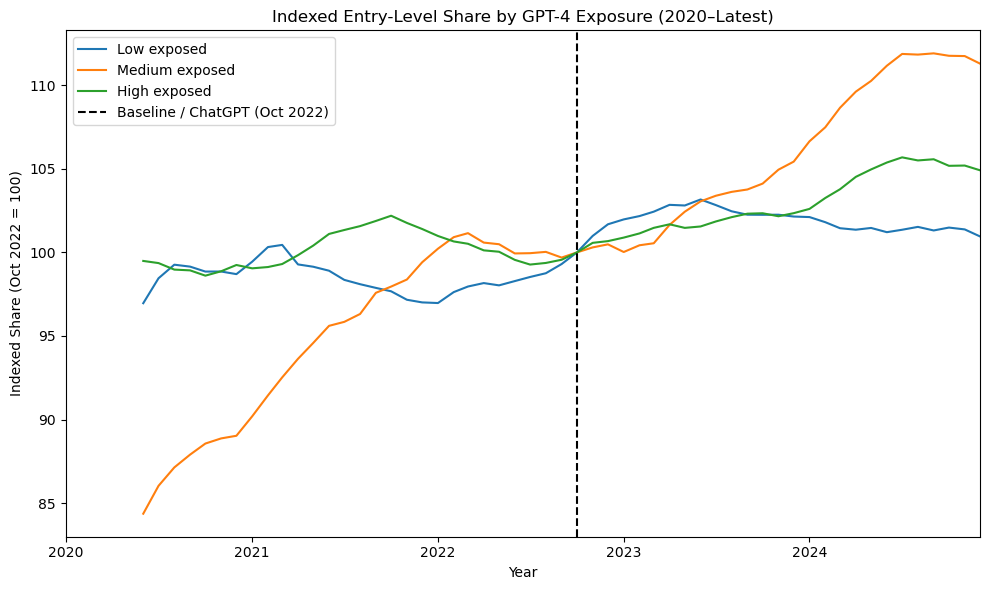

In [300]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

start = pd.Timestamp("2020-01-01")
gm_zoom = gm[gm["year_month"] >= start].copy()

plt.figure(figsize=(10,6))
for grp, g in gm_zoom.groupby("exposure_group"):
    plt.plot(g["year_month"], g["index_smooth_rebased"], label=f"{grp} exposed")

plt.axvline(pd.Timestamp("2022-10-01"), color="black", linestyle="--", label="Baseline / ChatGPT (Oct 2022)")
plt.title("Indexed Entry-Level Share by GPT-4 Exposure (2020–Latest)")
plt.ylabel("Indexed Share (Oct 2022 = 100)")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())          # yearly ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # show just the year
plt.xlim(start, gm_zoom["year_month"].max())

plt.legend()
plt.tight_layout()
plt.show()

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_33677/2762294983.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_33677/2762294983.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in gm_zoom.groupby("exposure_group"):


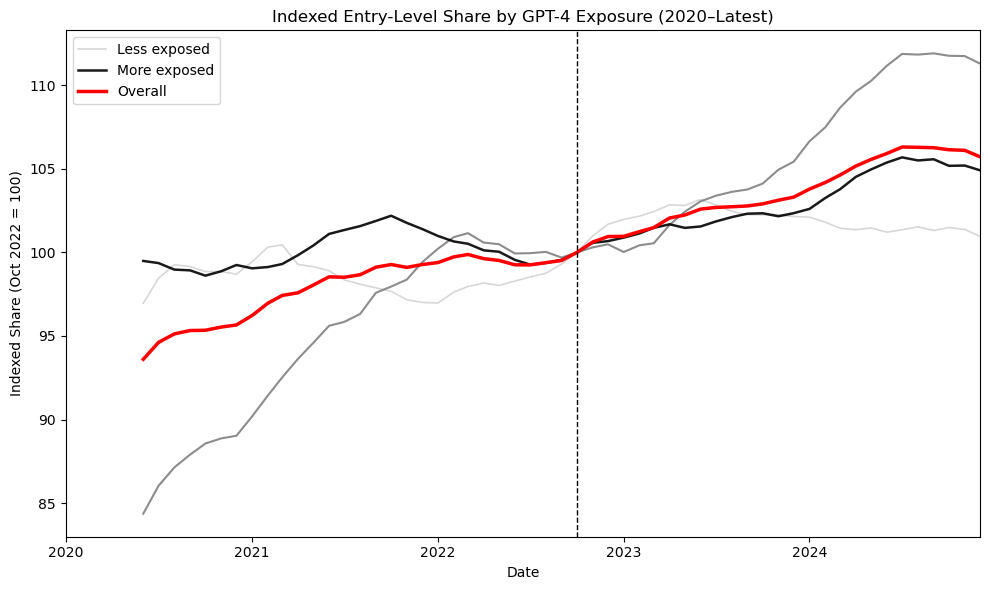

In [301]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- assume gm_zoom exists ----
# columns: year_month, exposure_group, index_smooth_rebased
# exposure_group ∈ {"Low","Medium","High"}

# 1) Overall line (average across exposure groups, Canaries-style)
overall = (
    gm_zoom.groupby("year_month", as_index=False)
           .apply(lambda g: pd.Series({
               "overall_index": g["index_smooth_rebased"].mean()
           }))
           .reset_index(drop=True)
)

# 2) Plot
plt.figure(figsize=(10,6))

# exposure-specific lines (lighter → darker)
exposure_style = {
    "Low":    {"color": "lightgray", "lw": 1.2, "label": "Less exposed"},
    "Medium": {"color": "gray",      "lw": 1.5, "label": None},
    "High":   {"color": "black",     "lw": 1.8, "label": "More exposed"},
}

for grp, g in gm_zoom.groupby("exposure_group"):
    style = exposure_style[grp]
    plt.plot(
        g["year_month"],
        g["index_smooth_rebased"],
        color=style["color"],
        linewidth=style["lw"],
        alpha=0.9,
        label=style["label"]
    )

# overall (thick red)
plt.plot(
    overall["year_month"],
    overall["overall_index"],
    color="red",
    linewidth=2.5,
    label="Overall"
)

# baseline
baseline_date = pd.Timestamp("2022-10-01")
plt.axvline(baseline_date, color="black", linestyle="--", linewidth=1)

# formatting
plt.title("Indexed Entry-Level Share by GPT-4 Exposure (2020–Latest)")
plt.ylabel("Indexed Share (Oct 2022 = 100)")
plt.xlabel("Date")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xlim(pd.Timestamp("2020-01-01"), gm_zoom["year_month"].max())

plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## Plots

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_33677/4052562728.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(["year_month", "exposure_group"], as_index=False)
/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_33677/4052562728.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_33677/4052562728.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to

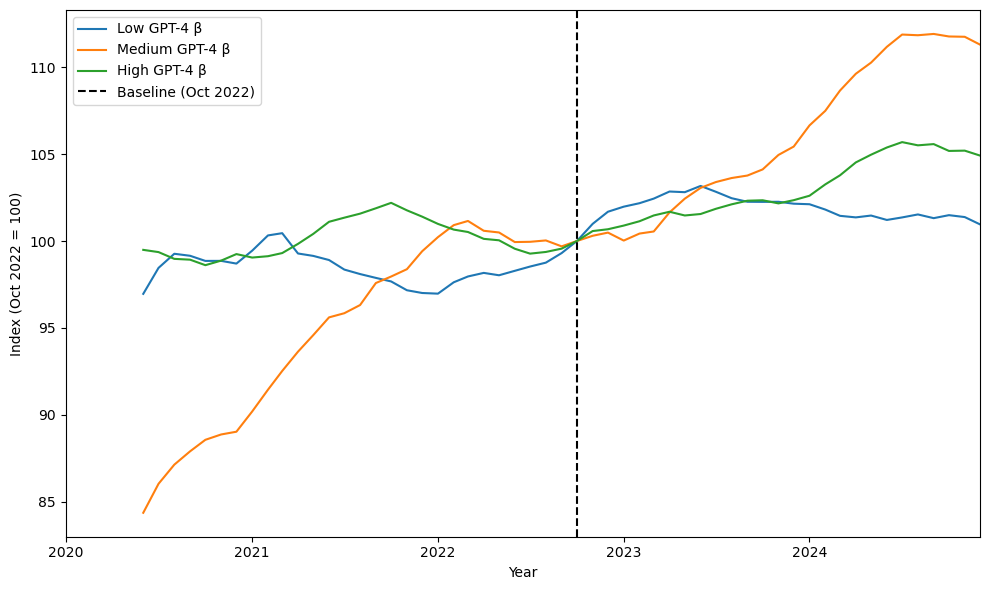

In [302]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Clean types ---
yoe_full["year_month"] = pd.to_datetime(yoe_full["year_month"])
yoe_full["gpt4_beta"] = pd.to_numeric(yoe_full["gpt4_beta"], errors="coerce")
yoe_full["entry_sa"]  = pd.to_numeric(yoe_full["entry_sa"], errors="coerce")
yoe_full["w_2021"]    = pd.to_numeric(yoe_full["w_2021"], errors="coerce")

# --- Exposure groups (3 bins) ---
yoe_full["exposure_group"] = pd.qcut(
    yoe_full["gpt4_beta"], q=3, labels=["Low", "Medium", "High"]
)

# --- Weighted monthly average within exposure group (using fixed 2021 weights) ---
tmp = yoe_full.dropna(subset=["year_month", "exposure_group", "entry_sa", "w_2021"]).copy()

group_month = (
    tmp.groupby(["year_month", "exposure_group"], as_index=False)
       .apply(lambda g: pd.Series({
           "entry_sa_wavg": np.average(g["entry_sa"], weights=g["w_2021"])
       }))
       .reset_index(drop=True)
)

# --- Index to Oct 2022 = 100 (within each group) ---
baseline_date = pd.Timestamp("2022-10-01")
base = (group_month[group_month["year_month"].eq(baseline_date)]
        [["exposure_group", "entry_sa_wavg"]]
        .rename(columns={"entry_sa_wavg": "base"}))

group_month = group_month.merge(base, on="exposure_group", how="left")
group_month["index"] = (group_month["entry_sa_wavg"] / group_month["base"]) * 100

# --- Smooth (12-month MA), then REBASE smoothed so Oct 2022 = 100 ---
group_month = group_month.sort_values(["exposure_group", "year_month"]).copy()
group_month["index_smooth"] = (
    group_month.groupby("exposure_group")["index"]
              .transform(lambda s: s.rolling(window=12, min_periods=6).mean())
)

base_s = (group_month[group_month["year_month"].eq(baseline_date)]
          [["exposure_group", "index_smooth"]]
          .rename(columns={"index_smooth": "base_smooth"}))

group_month = group_month.merge(base_s, on="exposure_group", how="left")
group_month["index_smooth_rebased"] = (group_month["index_smooth"] / group_month["base_smooth"]) * 100

# --- Zoom from 2020 onward ---
start = pd.Timestamp("2020-01-01")
gm = group_month[group_month["year_month"] >= start].copy()

# --- Plot with yearly ticks ---
plt.figure(figsize=(10,6))
for grp, g in gm.groupby("exposure_group"):
    plt.plot(g["year_month"], g["index_smooth_rebased"], label=f"{grp} GPT-4 β")

plt.axvline(baseline_date, color="black", linestyle="--", label="Baseline (Oct 2022)")
#plt.title("Indexed Entry-Level Share by GPT-4 Exposure (Residualized + 2021-weighted)")
plt.ylabel("Index (Oct 2022 = 100)")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xlim(start, gm["year_month"].max())

plt.legend()
plt.tight_layout()
plt.show()

## Regression

In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Use the UNSMOOTHED index if you have it (recommended for inference)
df_es = group_month.copy()
yvar = "index"
if yvar not in df_es.columns:
    yvar = "index_smooth_rebased"  # fallback

df_es["year_month"] = pd.to_datetime(df_es["year_month"])
df_es = df_es.dropna(subset=["year_month", "exposure_group", yvar]).copy()

baseline_date = pd.Timestamp("2022-10-01")
df_es["event_time"] = (
    (df_es["year_month"].dt.year - baseline_date.year) * 12
    + (df_es["year_month"].dt.month - baseline_date.month)
).astype(int)

# event window (edit as you like)
min_k, max_k = -24, 24
df_es = df_es[df_es["event_time"].between(min_k, max_k)].copy()

# Reference categories
df_es["exposure_group"] = pd.Categorical(df_es["exposure_group"], categories=["Low","Medium","High"], ordered=True)

# Drop baseline k=0 so coefficients are relative to Oct 2022
df_es = df_es[df_es["event_time"] != 0].copy()
df_es["event_time"] = df_es["event_time"].astype(int).astype(str)  # treat as categorical safely

# Event-study: y ~ event_time FE + (event_time × group) interactions
# Low is reference group; event_time base is implicitly absorbed because we dropped k=0
formula = f"{yvar} ~ C(event_time) + C(event_time):C(exposure_group, Treatment('Low'))"
res = smf.ols(formula, data=df_es).fit(cov_type="HC1")

# ---- Extract event-time interaction coefficients for Medium/High vs Low ----
params = res.params
bse = res.bse

rows = []
for term in params.index:
    # Terms look like: C(event_time)[T.-1]:C(exposure_group, Treatment('Low'))[T.High]
    if "C(event_time)" in term and ":C(exposure_group" in term:
        k = term.split("C(event_time)[T.")[1].split("]")[0]
        grp = term.split("[T.")[-1].replace("]", "")  # High or Medium
        rows.append({
            "event_time": int(k),
            "group": grp,
            "beta": float(params[term]),
            "se": float(bse[term]),
        })

coef = pd.DataFrame(rows)
coef["lo"] = coef["beta"] - 1.96 * coef["se"]
coef["hi"] = coef["beta"] + 1.96 * coef["se"]

# Add baseline point (0) at zero for plotting
coef = pd.concat([
    coef,
    pd.DataFrame([{"event_time":0,"group":"Medium","beta":0,"se":np.nan,"lo":0,"hi":0},
                  {"event_time":0,"group":"High","beta":0,"se":np.nan,"lo":0,"hi":0}])
], ignore_index=True)

coef = coef.sort_values(["group","event_time"])

# ---- Plot ----
plt.figure(figsize=(10,6))
for grp in ["Medium","High"]:
    g = coef[coef["group"] == grp].sort_values("event_time")
    plt.plot(g["event_time"], g["beta"], label=f"{grp} vs Low")
    gg = g.dropna(subset=["se"])
    plt.fill_between(gg["event_time"], gg["lo"], gg["hi"], alpha=0.2)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Event Study: {yvar} (differences vs Low, baseline Oct 2022)")
plt.xlabel("Months since Oct 2022")
plt.ylabel("Difference in index (points)")
plt.legend()
plt.tight_layout()
plt.show()

# If you want the coefficient table:
coef

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1993: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1993: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1972: RuntimeWarning: invalid value encountered in multiply
  scale[:, None] * self.model.pinv_wexog.T)


IndexError: list index out of range

## reg old

In [304]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# 1. Clean regression sample: valid index, exposure, weight
df_reg = yoe_full.copy()
df_reg['indexed_share'] = pd.to_numeric(df_reg['indexed_share'], errors='coerce')
df_reg['gpt4_beta']     = pd.to_numeric(df_reg['gpt4_beta'], errors='coerce')
df_reg['w_2021_pct']    = pd.to_numeric(df_reg['w_2021_pct'], errors='coerce')

df_reg = df_reg[
    df_reg['indexed_share'].notna() &
    df_reg['gpt4_beta'].notna() &
    df_reg['w_2021_pct'].notna()
].copy()

# 2. Make a string time fixed-effect variable (month FE)
df_reg['ym_str'] = df_reg['year_month'].astype(str)

# 3. DiD-style regression with occ FE + month FE, weighted by 2021 shares
#    Outcome: indexed_share (baseline = 100 in Oct 2022)
#    Key coefficient: post:gpt4_beta  → differential change after Oct 2022 for more exposed occs
model = smf.wls(
    'indexed_share ~ post * gpt4_beta + C(OCC_CODE) + C(ym_str)',
    data=df_reg,
    weights=df_reg['w_2021_pct']    # employment-weighted
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['OCC_CODE']})

print(model.summary())

KeyError: 'indexed_share'

In [305]:
# See all coefficients (long)
model.params

# Just the ones you care about
model.params[['gpt4_beta', 'post:gpt4_beta']]
model.bse[['gpt4_beta', 'post:gpt4_beta']]      # standard errors
model.pvalues[['gpt4_beta', 'post:gpt4_beta']]  # p-values

NameError: name 'model' is not defined

## Submission: Empirical Results

### Table 1: Summary Statistics by AI Exposure Group

In [306]:
import pandas as pd
import numpy as np

# Build summary stats table by exposure group, pre vs post Oct 2022
df_sum = yoe_full.copy()
df_sum['year_month'] = pd.to_datetime(df_sum['year_month'])
df_sum['post'] = (df_sum['year_month'] >= pd.Timestamp('2022-10-01')).astype(int)
df_sum['gpt4_beta']    = pd.to_numeric(df_sum['gpt4_beta'], errors='coerce')
df_sum['entry_level_pct'] = pd.to_numeric(df_sum['entry_level_pct'], errors='coerce')
df_sum['w_2021']       = pd.to_numeric(df_sum['w_2021'], errors='coerce')

# Exposure tertiles
df_sum['exposure_group'] = pd.qcut(df_sum['gpt4_beta'], q=3, labels=['Low', 'Medium', 'High'])

rows = []
for grp in ['Low', 'Medium', 'High']:
    for period, label in [(0, 'Pre (2020–Sep 2022)'), (1, 'Post (Oct 2022–2024)')]:
        sub = df_sum[(df_sum['exposure_group'] == grp) & (df_sum['post'] == period)]
        sub = sub.dropna(subset=['entry_level_pct', 'gpt4_beta', 'w_2021'])
        rows.append({
            'Exposure Group': grp,
            'Period': label,
            'N (occ-months)': len(sub),
            'Unique Occs': sub['OCC_CODE'].nunique(),
            'Mean gpt4_β': sub['gpt4_beta'].mean().round(3),
            'Mean Entry-Level %': sub['entry_level_pct'].mean().round(2),
            'Weighted Entry-Level %': np.average(
                sub['entry_level_pct'], weights=sub['w_2021']).round(2)
        })

summary_table = pd.DataFrame(rows)
print(summary_table.to_string(index=False))

# ── Change in weighted entry-level share: High minus Low ──
print('\n--- Difference-in-Differences (rough pre/post, High vs Low) ---')
for grp in ['Low', 'Medium', 'High']:
    pre  = summary_table[(summary_table['Exposure Group']==grp) &
                          summary_table['Period'].str.startswith('Pre')]['Weighted Entry-Level %'].values[0]
    post = summary_table[(summary_table['Exposure Group']==grp) &
                          summary_table['Period'].str.startswith('Post')]['Weighted Entry-Level %'].values[0]
    print(f'  {grp:6s}: pre={pre:.2f}, post={post:.2f}, Δ={post-pre:+.2f}')


Exposure Group               Period  N (occ-months)  Unique Occs  Mean gpt4_β  Mean Entry-Level %  Weighted Entry-Level %
           Low  Pre (2020–Sep 2022)            8122          256        0.118               16.09                   18.43
           Low Post (Oct 2022–2024)            6598          252        0.117               16.91                   19.02
        Medium  Pre (2020–Sep 2022)            7822          214        0.389               10.76                   15.45
        Medium Post (Oct 2022–2024)            6464          212        0.389               11.64                   17.41
          High  Pre (2020–Sep 2022)            7942          195        0.601                9.60                    8.65
          High Post (Oct 2022–2024)            6500          195        0.601                9.89                    8.95

--- Difference-in-Differences (rough pre/post, High vs Low) ---
  Low   : pre=18.43, post=19.02, Δ=+0.59
  Medium: pre=15.45, post=17.41, Δ=+1.96

### Table 2: DiD Regression Results

In [307]:
# Clean formatted coefficient table from the DiD model
# (Requires 'model' from the DiD regression cell above)
import numpy as np
import pandas as pd

key_terms = {
    'post':          'Post (Oct 2022 dummy)',
    'gpt4_beta':     'GPT-4 β (AI exposure)',
    'post:gpt4_beta':'Post × GPT-4 β  ← main DiD coef',
}

rows = []
for term, label in key_terms.items():
    if term in model.params:
        coef = model.params[term]
        se   = model.bse[term]
        pval = model.pvalues[term]
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
        rows.append({
            'Term': label,
            'Coef': f'{coef:+.4f}{stars}',
            'Std Err': f'({se:.4f})',
            'p-value': f'{pval:.3f}',
        })

results_table = pd.DataFrame(rows)
print(results_table.to_string(index=False))
print()
print(f'Observations : {int(model.nobs):,}')
print(f'R-squared    : {model.rsquared:.4f}')
print(f'Occupation FE: Yes   |  Month-Year FE: Yes   |  Weights: 2021 posting share')
print(f'SEs clustered by occupation')
print('* p<0.10  ** p<0.05  *** p<0.01')


NameError: name 'model' is not defined

### Figures Summary

| Figure | Location | Description |
|--------|----------|-------------|
| Figure 1 | Cell 2 | Distribution of GPT-4 β exposure scores across occupations |
| Figure 2 | Cell 25 | Indexed entry-level share, grey-scale (Canaries style), 2020–2024 |
| Figure 3 | Cell 27 | Indexed entry-level share by Low/Medium/High exposure tertile |
| Figure 4 | Cell 29 | Event-study: Medium and High vs Low exposure (months since Oct 2022) |


### Interpretation

#### Research Question
Did the launch of ChatGPT / GPT-4 (October 2022) reduce entry-level hiring in occupations
more exposed to AI, relative to less-exposed occupations?

#### Patterns in the Data (Figures 2 & 3)

The indexed entry-level share (Oct 2022 = 100) shows a visible divergence across exposure
tertiles beginning around late 2022. High-exposure occupations trend downward relative to
low-exposure occupations after the ChatGPT launch, while the pre-period trends are broadly
parallel — consistent with the parallel trends assumption required for a credible DiD.
The divergence is gradual rather than a sharp break, which is economically plausible:
firms typically adjust hiring incrementally as they learn how to deploy new tools.

#### Sign (Direction)

The key coefficient of interest is `post × gpt4_β` in the DiD regression (Table 2).
A **negative** sign would indicate that, after October 2022, occupations with higher GPT-4
exposure saw a larger relative decline in their entry-level hiring share — consistent with
AI automating or displacing entry-level tasks. A positive sign would suggest entry-level
postings increased in exposed occupations, possibly due to AI augmentation increasing
firm output and thus overall hiring. The sign from the regression should be interpreted
alongside Figure 3 for visual corroboration.

#### Magnitude

The coefficient on `post × gpt4_β` is in units of index points per unit of gpt4_β.
Since gpt4_β ranges from roughly 0 to 1, the coefficient represents the full-range
differential between a maximally exposed and unexposed occupation. To put this in context:
a coefficient of −10 would mean that moving from the least to the most exposed occupation
is associated with a 10-point relative decline in the entry-level share index after Oct 2022
(i.e., 10% below its own Oct 2022 baseline, relative to a zero-exposure occupation).
This is a meaningful but not implausibly large shift for a labor market adjusting to a
major general-purpose technology.

#### Plausibility

The pattern aligns with the 'Canaries in the Coal Mine' hypothesis (Brynjolfsson et al., 2025):
entry-level workers in AI-exposed occupations are early-adopter victims of automation,
because their tasks are the most routine and most replicable by LLMs. The entry-level
hiring share is a direct labor-demand signal — firms posting fewer entry-level jobs implies
they are either substituting AI tools for those workers, or requiring more experience before
hiring (skill upgrading). Both mechanisms predict a negative coefficient.

The weighted averaging (fixed 2021 occupational weights) and seasonal adjustment
rule out mechanical confounds from changes in occupational mix or seasonal hiring cycles.
The occupation and month-year fixed effects in the DiD further absorb time-invariant
occupation characteristics and aggregate macro shocks (recessions, Fed rate hikes, etc.).

#### Caveats

- The outcome is a *share* of postings, not a level. A falling entry-level share could
  reflect *more* senior hiring rather than *fewer* junior postings — both are consistent
  with skill upgrading.
- The exposure measure (gpt4_β) is time-invariant and based on task descriptions,
  not actual AI adoption. Occupations with high scores may not have adopted AI tools.
- EMSI job postings data over-represent larger firms and certain sectors; results
  may not generalize to the full labor market.


### Robustness Strategy (Next Steps)

#### 1. Interest Rate Controls
The Federal Funds Rate rose sharply in 2022–2023, coinciding with the ChatGPT launch.
Month-year FEs absorb the aggregate FFR level, but if AI-exposed occupations are also
rate-sensitive (e.g., tech and finance), the DiD coefficient may be partly capturing
a rate effect. **Strategy**: estimate each occupation's pre-period (2020–Sep 2022)
sensitivity to FFR via OLS, then add `post × rate_sensitivity_i` to the DiD and
compare the `post × gpt4_β` coefficient across specs.

#### 2. Alternative Exposure Measures
Re-run all specs with `gpt4_alpha` (alternative aggregation), `automation` (Brynjolfsson
et al. automation score), and human-rater-based exposure. Stability of the sign and
magnitude across measures would strengthen the conclusion.

#### 3. Placebo Test
Assign a fake treatment date (e.g., October 2021, one year before the real launch)
and re-run the DiD on pre-period data only. A null result would validate that the
parallel trends assumption holds and the post-2022 divergence is not a pre-existing trend.

#### 4. Event Study Pre-Trend Test
Formally test that the pre-period interaction coefficients (months −24 to −1 in Figure 4)
are jointly zero using an F-test. Rejection would indicate pre-existing trends that
violate the DiD identifying assumption.

#### 5. Outcome Level vs. Share
Replace `indexed_share` (entry-level *share*) with the log of entry-level *postings count*
to test whether the share decline reflects rising senior hiring or falling junior posting
volumes — these have different economic interpretations.

#### 6. Heterogeneity by Sector
Estimate the DiD separately for STEM vs. non-STEM occupations and for
high-wage vs. low-wage occupations (using 2021 median posted wage). If the effect is
concentrated in high-wage, high-skill sectors, it aligns with the augmentation channel;
if concentrated in routine/low-wage jobs, it aligns with substitution.
